
<h2 id="2.2-PPAC-%E4%BF%A1%E5%8F%B7%E5%A4%84%E7%90%86-II">2.2 PPAC 信号处理-II</h2><h2 id="1.-Tracking">1. Tracking</h2><p>利用多个 PPAC 的位置 (x,y,z) 信息进行 tracking 的原理如下图所示。由于 PPAC 的探测效率通常小于 100%，因此对于每个入射粒子，往往只有部分 PPAC 能够在 x 或 y 方向给出有效的位置信息。</p>
<p>假设对于某一入射粒子，有两个或两个以上探测器给出了有效的测量位置信息（如图中的红点所示，例如 1Ax, 2Ax 等），入射粒子在 x-z 或 y-z 平面上的飞行径迹即可由这些有效点进行线性拟合得到。</p>
<p>得到径迹的线性方程后，束流线上其他任意位置 (z) 处的 (x,y) 坐标，均可利用上述方程通过内插或外推计算得出。图中黑点即代表由线性方程计算/拟合得到的位置（它代表了我们所能推测出的粒子实际飞行路径）。</p>
<p><img alt="setup" src="fig/tracking.png"/></p>
<hr/>
<h3 id="%E6%9C%AC%E5%AE%9E%E9%AA%8C%E4%B8%AD%E9%87%87%E7%94%A8%E7%9A%84%E9%87%8D%E5%BB%BA%E7%AD%96%E7%95%A5">本实验中采用的重建策略</h3><p>在实际实验中，若强制要求单层探测器必须同时给出 $(x,y)$ 二维有效信号才参与拟合，会导致严重的整体探测效率损失。因此实际上$x$ 方向与 $y$ 方向的径迹重建是完全独立进行的。即：只要某层探测器测得了有效的 $x$ 坐标，即便其 $y$ 信号缺失，该点仍独立参与 $x-z$ 平面的径迹拟合。</p>
<p><strong>2. 径迹有效条件</strong>
对于 $x$ 或 $y$ 径迹，必须满足以下逻辑条件之一才被视为有效重建：</p>
<ul>
<li><p><strong>情况一：</strong> 最靠近下游的 <strong>F8PPAC3 具有有效信号</strong></p>
<ul>
<li>同时要求上游的 F8PPAC1 和 F8PPAC2 中，至少有 1 层 PPAC 提供有效信号。</li>
</ul>
</li>
<li><p><strong>情况二：</strong> 最靠近下游的 <strong>F8PPAC3 无有效信号</strong></p>
<ul>
<li>则完全依赖上游探测器，需满足以下 <strong>a) 或 b)</strong>：<ul>
<li><strong>a)</strong> F8PPAC1 和 F8PPAC2 中，合计有 <strong>3 层或 3 层以上</strong>的 PPAC 提供有效信号。</li>
<li><strong>b)</strong> 若合计仅有 <strong>2 层</strong> PPAC 提供有效信号，则要求这两层<strong>必须分别来自</strong> F8PPAC1 和 F8PPAC2。
<em>(若仅有的2层信号来自同一位置（如都在 F8PPAC1 内），因两点间距过近，向靶点外推时会产生巨大的角度误差)</em></li>
</ul>
</li>
</ul>
</li>
</ul>
<hr/>
<h4 id="%E6%9D%9F%E6%B5%81%E5%BE%84%E8%BF%B9%E9%87%8D%E5%BB%BA%E7%BB%93%E6%9E%9C%EF%BC%88%E6%89%80%E6%9C%89PPAC%E7%9A%84%E4%BF%A1%E6%81%AF%E9%83%BD%E6%9C%89x/y%E4%BD%8D%E7%BD%AE%E4%BF%A1%E6%81%AF%EF%BC%89">束流径迹重建结果（所有PPAC的信息都有x/y位置信息）</h4><p><img alt="setup" src="fig/pos_track.png"/></p>
<h2 id="2.-ROOT-%E6%96%87%E4%BB%B6%E4%B8%AD-TTree-%E7%9A%84-Branch-%E8%AF%B4%E6%98%8E">2. ROOT 文件中 TTree 的 Branch 说明</h2><p>本实验使用的ROOT文件中，已完成位置刻度的 PPAC 数据存储在二维数组 <code>PPACF8[i][j]</code> 中。</p>
<ul>
<li>$z$ 坐标：代表各探测器平面在束流线上的绝对 $z$ 方向位置，由实验室几何测量事先给定。</li>
<li>$x/y/z$坐标：单位mm。</li>
<li>当出现位置计算超界、信号堆积 (Pile-up) 或缺失时，数据统一用 <code>-999</code> 或 <code>-1000</code> 填充。</li>
</ul>
<p><strong>数据映射关系表（从原始数据到物理分析变量）：</strong></p>
<table>
<thead>
<tr>
<th style="text-align:left">探测器层级</th>
<th style="text-align:left">原始 Branch</th>
<th style="text-align:left">物理意义 (已刻度)</th>
<th style="text-align:left">讲义代码对应变量</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:left"><strong>PPAC 1 Layer A</strong></td>
<td style="text-align:left"><code>PPACF8[0][0]</code><br/><code>PPACF8[0][1]</code><br/><code>PPACF8[0][2]</code><br/><code>PPACF8[0][3]</code></td>
<td style="text-align:left">$X$ 坐标 (mm)<br/>$Y$ 坐标 (mm)<br/>$X$ 平面对应的 $Z$ 坐标<br/>$Y$ 平面对应的 $Z$ 坐标</td>
<td style="text-align:left"><code>xx[0]</code><br/><code>yy[0]</code><br/><code>xz[0]</code><br/><code>yz[0]</code></td>
</tr>
<tr>
<td style="text-align:left"><strong>PPAC 1 Layer B</strong></td>
<td style="text-align:left"><code>PPACF8[1][0~4]</code></td>
<td style="text-align:left">(同上结构，含 Anode 时间)</td>
<td style="text-align:left"><em>(本示例暂未使用)</em></td>
</tr>
<tr>
<td style="text-align:left"><strong>PPAC 2 Layer A</strong></td>
<td style="text-align:left"><code>PPACF8[2][0~4]</code></td>
<td style="text-align:left">(同上结构)</td>
<td style="text-align:left"><code>xx[1], yy[1]</code><br/><code>xz[1], yz[1]</code></td>
</tr>
<tr>
<td style="text-align:left"><strong>PPAC 2 Layer B</strong> <br/><em>(作为待测层 DUT)</em></td>
<td style="text-align:left"><code>PPACF8[3][0~4]</code></td>
<td style="text-align:left">(同上结构)</td>
<td style="text-align:left"><code>xx2b[0], yy2b[0]</code><br/><code>xz2b, yz2b</code><br/><code>anode2b</code></td>
</tr>
<tr>
<td style="text-align:left"><strong>PPAC 3</strong></td>
<td style="text-align:left"><code>PPACF8[4][0~4]</code></td>
<td style="text-align:left">(同上结构)</td>
<td style="text-align:left"><code>xx[2], yy[2]</code><br/><code>xz[2], yz[2]</code></td>
</tr>
</tbody>
</table>
<hr/>
<hr/>
<h2 id="3.-%E5%BE%84%E8%BF%B9%E9%87%8D%E5%BB%BA-(Tracking)-%E4%BA%8B%E4%BE%8B%E4%BB%A3%E7%A0%81">3. 径迹重建 (Tracking) 事例代码</h2><p>下面示例代码 <strong>假设 1A, 2A, 3 这三个探测器均给出了有效位置信息</strong>，利用这三点进行直线拟合，并将径迹外推，用来评估 2B 探测器的各项探测效率及系统分辨率。</p>
<p>算法步骤如下：</p>
<ul>
<li><strong>1. 空间独立直线拟合：</strong><ul>
<li>$x-z$ 平面拟合直线方程 $x = f_x(z)$，使用已知数据点：<code>(xx[0],xz[0]), (xx[1],xz[1]), (xx[2],xz[2])</code></li>
<li>$y-z$ 平面拟合直线方程 $y = f_y(z)$，使用已知数据点：<code>(yy[0],yz[0]), (yy[1],yz[1]), (yy[2],yz[2])</code></li>
</ul>
</li>
<li><strong>2. 残差 (Residual) 计算（用于评估位置分辨率）：</strong><ul>
<li>测量值与拟合值的差：$dx[i] = xx[i] - f_x(xz[i])$ ； $dy[i] = yy[i] - f_y(yz[i])$ $(i=0,1,2)$</li>
</ul>
</li>
<li><strong>3. 待测层 F8PPAC2_B (2B) 的对比：</strong><ul>
<li><strong>实验测量坐标：</strong> <code>(xx2b[0], xz2b)</code> 和 <code>(yy2b[0], yz2b)</code></li>
<li><strong>外推预期坐标：</strong> 利用拟合直线算得 <code>(xx2b[1], xz2b)</code> 和 <code>(yy2b[1], yz2b)</code></li>
<li><strong>阳极触发信号：</strong> <code>anode2b</code>（用于求阳极本征效率）</li>
</ul>
</li>
<li><strong>4. 物理靶位坐标外推：</strong><ul>
<li>利用拟合直线外推至靶点平面（假设靶位于 $z=0$），求得靶上坐标 <code>(tx, ty)</code>。</li>
</ul>
</li>
</ul>



<h1 id="%E9%9D%B6%E7%82%B9%E5%9D%90%E6%A0%87-$(t_x,-t_y)$-%E4%B8%8E%E5%87%BA%E5%B0%84%E8%A7%92-$%5Ctheta$-%E7%9A%84%E8%AF%AF%E5%B7%AE%E8%AF%84%E4%BC%B0">靶点坐标 $(t_x, t_y)$ 与入射方向的投影角 $\theta$ 的误差评估</h1><h3 id="1.-%E7%89%A9%E7%90%86%E5%8A%A8%E6%9C%BA%EF%BC%9A%E4%B8%BA%E4%BB%80%E4%B9%88%E8%A6%81%E9%80%90%E4%BA%8B%E4%BB%B6%E8%AF%84%E4%BC%B0%E8%BF%BD%E8%B8%AA%E8%AF%AF%E5%B7%AE%EF%BC%9F">1. 物理动机：为什么要逐事件评估追踪误差？</h3><p>在真实的物理实验中，分析中会采用不同的径迹重建（Tracking）策略。例如：</p>
<ul>
<li><strong>策略 A：</strong> 3 层探测器完美击中 $\to$ 杠杆臂长，拟合精度极高。</li>
<li><strong>策略 B：</strong> 仅有 2 层探测器击中 $\to$ 勉强定迹，拟合误差巨大。</li>
</ul>
<p>当我们为每一个事件计算出专属的物理误差（$\sigma_{t_x}, \sigma_\theta$）并存入  TTree 后，在后续的物理分析中，可以通过以下 <strong>三种具体的编程手段</strong> 来统一处理这些质量参差不齐的数据：</p>
<h4 id="%E7%94%A8%E6%B3%95%E4%B8%80%EF%BC%9AQuality-Cut">用法一：Quality Cut</h4><p>有了误差后，不同 tracking 策略的好坏被统一量化。在 ROOT 中画图或提取数据时，通过TCut选择不同误差的事件：</p>
<div class="highlight"><pre><span></span><span class="c1">// 只要外推到靶上的误差小于 1.5 mm 的事件</span>
<span class="n">TCut</span><span class="w"> </span><span class="n">good_track_cut</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="s">"sigma_tx &lt; 1.5 &amp;&amp; sigma_theta &lt; 0.05"</span><span class="p">;</span>
<span class="n">tree</span><span class="o">-&gt;</span><span class="n">Draw</span><span class="p">(</span><span class="s">"tx &gt;&gt; h1"</span><span class="p">,</span><span class="w"> </span><span class="n">good_track_cut</span><span class="p">);</span>
</pre></div>
<h4 id="%E7%94%A8%E6%B3%95%E4%BA%8C%EF%BC%9AInverse-Variance-Weighting">用法二：Inverse-Variance Weighting</h4><p>如果物理目标是测量一个确定的中心值（例如：寻找束流打在靶上的绝对中心位置，或者拟合某个共振态的确定散射角），不能对所有事件取简单的算术平均。
应该使用<strong>逆方差（误差的平方倒数）作为每个事件的权重 $w_i$</strong>：
$$ w_i = \frac{1}{\sigma_i^2} $$
<strong>数学原理实现：</strong></p>
<div class="highlight"><pre><span></span><span class="kt">double</span><span class="w"> </span><span class="n">sum_weight</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">0</span><span class="p">;</span>
<span class="kt">double</span><span class="w"> </span><span class="n">sum_value</span><span class="w">  </span><span class="o">=</span><span class="w"> </span><span class="mi">0</span><span class="p">;</span>

<span class="k">for</span><span class="w"> </span><span class="p">(</span><span class="kt">int</span><span class="w"> </span><span class="n">i</span><span class="o">=</span><span class="mi">0</span><span class="p">;</span><span class="w"> </span><span class="n">i</span><span class="o">&lt;</span><span class="n">nentries</span><span class="p">;</span><span class="w"> </span><span class="n">i</span><span class="o">++</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">    </span><span class="n">tree</span><span class="o">-&gt;</span><span class="n">GetEntry</span><span class="p">(</span><span class="n">i</span><span class="p">);</span>
<span class="w">    </span><span class="k">if</span><span class="w"> </span><span class="p">(</span><span class="n">sigma_tx</span><span class="w"> </span><span class="o">&lt;=</span><span class="w"> </span><span class="mi">0</span><span class="p">)</span><span class="w"> </span><span class="k">continue</span><span class="p">;</span><span class="w"> </span><span class="c1">// 排除无效点</span>
<span class="w">    </span>
<span class="w">    </span><span class="kt">double</span><span class="w"> </span><span class="n">weight</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mf">1.0</span><span class="w"> </span><span class="o">/</span><span class="w"> </span><span class="p">(</span><span class="n">sigma_tx</span><span class="w"> </span><span class="o">*</span><span class="w"> </span><span class="n">sigma_tx</span><span class="p">);</span><span class="w"> </span><span class="c1">// 误差越小，权重呈按误差平方的倒数暴增</span>
<span class="w">    </span><span class="n">sum_value</span><span class="w">  </span><span class="o">+=</span><span class="w"> </span><span class="n">tx</span><span class="w"> </span><span class="o">*</span><span class="w"> </span><span class="n">weight</span><span class="p">;</span>
<span class="w">    </span><span class="n">sum_weight</span><span class="w"> </span><span class="o">+=</span><span class="w"> </span><span class="n">weight</span><span class="p">;</span>
<span class="p">}</span>
<span class="kt">double</span><span class="w"> </span><span class="n">final_tx_center</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">sum_value</span><span class="w"> </span><span class="o">/</span><span class="w"> </span><span class="n">sum_weight</span><span class="p">;</span>
</pre></div>
<hr/>
<h3 id="2.-%E5%8D%8F%E6%96%B9%E5%B7%AE%E7%9F%A9%E9%98%B5-(Covariance-Matrix)">2. 协方差矩阵 (Covariance Matrix)</h3><p>假设在 $X-Z$ 平面内用线性方程 $x(z) = p_0 + p_1 \cdot z$ 拟合粒子径迹。
最小二乘法在给出截距 $p_0$ 和斜率 $p_1$ 的同时，必然会给出一个 $2 \times 2$ 的<strong>协方差矩阵 $C$</strong>：</p>
<p>$$ C = \begin{pmatrix} \sigma_{p_0}^2 &amp; Cov(p_0, p_1) \\ Cov(p_1, p_0) &amp; \sigma_{p_1}^2 \end{pmatrix} $$</p>
<ul>
<li><strong>对角线元素：</strong> 分别是截距和斜率自身误差的平方（方差）。</li>
<p>slope 与 intercept 的 covariance 取决于 z 原点及探测器布局，符号不总为负。外推误差使用完整协方差矩阵，不能预先假定忽略交叉项一定使误差偏大或偏小。</p>
</ul>
<hr/>
<h3 id="3.-%E5%8E%9F%E7%90%86%E6%8E%A8%E5%AF%BC%EF%BC%9A%E5%A4%96%E6%8E%A8%E9%9D%B6%E7%82%B9-$(t_x)$-%E4%B8%8E%E5%87%BA%E5%B0%84%E8%A7%92-$(%5Ctheta)$-%E7%9A%84%E8%AF%AF%E5%B7%AE%E4%BC%A0%E9%80%92">3. 原理推导：外推靶点 $(t_x)$ 与入射方向的投影角 $(\theta)$ 的误差传递</h3><p>假设物理靶位于 $z = z_{target}$ 处。</p>
<h4 id="A.-%E9%9D%B6%E4%B8%8A%E4%BD%8D%E7%BD%AE-$t_x$-%E7%9A%84%E8%AF%AF%E5%B7%AE%E6%8E%A8%E5%AF%BC%EF%BC%88%E7%BA%BF%E6%80%A7%E4%BC%A0%E9%80%92%EF%BC%89">A. 靶上位置 $t_x$ 的误差推导（线性传递）</h4><p>根据直线方程，外推点的计算公式为：$t_x = p_0 + p_1 \cdot z_{target}$。
利用多元函数误差传递公式：
$$ \sigma_{f(p_0, p_1)}^2 = \left( \frac{\partial f}{\partial p_0} \right)^2 \sigma_{p_0}^2 + \left( \frac{\partial f}{\partial p_1} \right)^2 \sigma_{p_1}^2 + 2 \left( \frac{\partial f}{\partial p_0} \right) \left( \frac{\partial f}{\partial p_1} \right) Cov(p_0, p_1) $$</p>
<p>代入偏导数（$\frac{\partial t_x}{\partial p_0} = 1$, $\frac{\partial t_x}{\partial p_1} = z_{target}$），得到靶点位置的真实方差：
$$ \mathbf{\sigma_{t_x}^2 = \sigma_{p_0}^2 + (z_{target})^2 \cdot \sigma_{p_1}^2 + 2 \cdot z_{target} \cdot Cov(p_0, p_1)} $$
<em>(注：Y 方向的 $t_y$ 误差推导与 X 方向完全相同，只需将 X 平面的拟合参数代入即可。)</em></p>
<h4 id="B.-%E7%89%A9%E7%90%86%E5%87%BA%E5%B0%84%E8%A7%92-$%5Ctheta$-%E7%9A%84%E8%AF%AF%E5%B7%AE%E6%8E%A8%E5%AF%BC%EF%BC%88%E9%9D%9E%E7%BA%BF%E6%80%A7%E4%BC%A0%E9%80%92%EF%BC%89">B. 物理入射方向的投影角 $\theta$ 的误差推导（非线性传递）</h4><p>拟合出的斜率 $p_1$ 等于角度的正切值，真正的物理角度为：$\theta = \arctan(p_1)$。
利用一元非线性误差传递公式：
$$ \sigma_\theta^2 = \left( \frac{d\theta}{dp_1} \right)^2 \sigma_{p_1}^2 $$
根据微积分导数公式 $\frac{d}{dx}\arctan(x) = \frac{1}{1+x^2}$，得到角度的真实绝对误差：
$$ \mathbf{\sigma_\theta = \frac{\sigma_{p_1}}{1 + p_1^2}} $$</p>
<p>\(\arctan k_x\)、\(\arctan k_y\) 是两个投影角；相对 z 轴的极角为 \(\theta=\arctan\sqrt{k_x^2+k_y^2}\)。两点也可确定直线并在已知测量误差下传播参数误差，但 NDF=0，不能用 χ²/NDF 检验拟合。</p><p>束斑中不同事例的真实位置本来就有分布，束斑中心不应仅按各事例的 tracking 误差加权；inverse-variance 平均要求它们测量同一个参数，或在模型中同时纳入束斑的本征宽度。</p>


<hr/>
<h2 id="4.-%E4%BD%8D%E7%BD%AE%E5%88%86%E8%BE%A8%E7%8E%87">4. 位置分辨率</h2><p>在实验中，测定探测器的本征位置分辨率是评估径迹重建质量和动量/角度分辨率的前提。通常有两种测定方法：</p>
<h4 id="2.1-%E5%87%86%E7%9B%B4%E6%9D%9F%E5%88%BB%E5%BA%A6%E6%96%B9%E6%B3%95%EF%BC%88%E7%A6%BB%E7%BA%BF%E6%B5%8B%E8%AF%95-/-%E6%94%BE%E5%B0%84%E6%BA%90%EF%BC%89">2.1 准直束刻度方法（离线测试 / 放射源）</h4><p><img alt="" src="fig/pos_res.png"/></p>
<p>该方法通常在离线实验室中，利用低能放射源和准直狭缝（Collimator）进行。</p>
<ul>
<li><strong>理想高斯展宽模型：</strong>
通过准直孔将粒子准直后打入探测器。此时测得的表观位置分辨率 $\sigma$ 是探测器本征分辨率 $\sigma_0$ 与准直孔几何展宽 $\sigma_{geo}$ 的卷积（近似为高斯叠加）：
$$ \sigma^2 = \sigma_0^2 + \sigma_{geo}^2 $$
其中，$\sigma_{geo}$ 由准直孔的物理孔径引入（见图 a）。通过反推即可得到 $\sigma_0$。</li>
<li><strong>局限性一：源与真实束流的电离差异</strong>
气体探测器的本征分辨率 $\sigma_0$ 强烈依赖于入射粒子的<strong>比电离能损 ($dE/dx$)</strong>、<strong>原初电离统计涨落</strong>以及<strong>产生 $\delta$ 电子的射程</strong>。因此，用低能 $\alpha$ 放射源测出的 $\sigma_0$，只能证明探测器硬件完好，<strong>不能直接等同于</strong>高能重离子束流条件下的真实分辨率。</li>
<li><strong>局限性二：高能束流的“边缘散射（Slit Scattering）”</strong>
如果在真实束流线上强行使用准直孔（图 b），高能粒子在穿过准直孔边缘时会发生严重的<strong>多重库仑散射（MCS）</strong>。这不仅会使得 $\sigma_{geo}$ 的几何关联失效，更会在位置谱上产生巨大的非高斯拖尾（Tail / Halo），彻底淹没探测器真实的 $\sigma_0$。</li>
</ul>
<hr/>
<h4 id="2.2-%E5%A4%9A%E6%8E%A2%E6%B5%8B%E5%99%A8%E5%BE%84%E8%BF%B9%E6%AE%8B%E5%B7%AE%E6%B3%95">2.2 多探测器径迹残差法</h4><p>鉴于准直方法的局限性，在真实的高能物理实验中，<strong>可靠的方法</strong>是利用多层探测器系统，在真实束流和真实数据获取条件下，通过<strong>径迹残差（Residuals）</strong>来逆推分辨率。</p>
<ul>
<li><p><strong>残差（Residual）的定义：</strong>
选择被全部 PPAC（如 5 层）同时探测到的“好事件”进行空间直线拟合。定义第 $i$ 层探测器的测量坐标 $x^i$ 与拟合径迹在该层的预期坐标 $x_{track}^i$ 之差为<strong>残差 $\Delta x^i$</strong>：
$$ \Delta x^i = x^i - x_{track}^i $$</p>
</li>
<li><p>在 $z_i$ 位置观察到的<strong>残差 $\Delta x^i$</strong>，实际上是由两个独立成分叠加而成的：</p>
</li>
</ul>
<ol>
<li><strong>探测器本身的测量涨落 $\sigma_0$</strong>，即位置分辨。</li>
<li><strong>拟合直线的误差 $\sigma_{track}$</strong>：这正是通过上一节协方差矩阵在 $z_i$ 处算出的不确定度。</li>
</ol>
<p>提取 $\sigma_0$，实验上常用<strong>“排除拟合法”</strong>：即在拟合直线时，不使用第 $i$ 层的数据，而只用其他层连成直线。</p>
<p>此时，由于第 $i$ 层的测量值与外推直线完全独立，残差的方差是两者方差的<strong>直接相加</strong>：
$$\sigma_{residual}^2 = \sigma_0^2 + \sigma_{track}^2(z_i)$$</p>
<hr/>
<h2 id="5.-PPAC-%E6%8E%A2%E6%B5%8B%E6%95%88%E7%8E%87">5. PPAC 探测效率</h2><p><img alt="" src="fig/pos_eff.png"/></p>
<p>理想情况下，若有 $N$ 个粒子真实穿过了探测器的灵敏区域（Active Area），而探测器实际成功记录并解析出位置信息的事件数为 $N_{det}$，则该探测器的绝对探测效率定义为：
$$\epsilon = \frac{N_{det}}{N}$$</p>
<p>在实际束流实验中，由于我们无法预知真实的 $N$，通常采用以下两种典型的数据分析方法来评估效率：</p>
<p><strong>方法一：位置读出效率（基于内部信号符合，对应图 a）</strong></p>
<ul>
<li><strong>物理意义：</strong> 评估当气体发生有效雪崩后，阴极成功读取出位置坐标的概率。</li>
<li><strong>计算方法：</strong> 将 PPAC 的<strong>阳极 (Anode) 触发信号计数</strong>作为分母（代表测到粒子确实穿过探测器），将<strong>阴极 (Cathode) 具有位置信息的计数</strong>作为分子。</li>
</ul>
<p><strong>方法二：基于径迹外推的绝对探测效率（参考探测器法，对应图 b）</strong></p>
<ul>
<li><strong>物理意义：</strong> 利用其他探测器作为基准，评估待测探测器的实际探测能力。</li>
<li><strong>计算方法：</strong><ol>
<li>选择任意两层（或多层）具有位置信号的 PPAC 作为<strong>参考探测器（图b中的 i, j）</strong>，拟合出粒子径迹。</li>
<li><strong>分母 ($N_{ij}$)：</strong> 将上述径迹外推至<strong>待测探测器（图b中的 k）</strong>的位置，统计预期穿过其灵敏面积的所有事件总数。</li>
<li><strong>分子 ($N_{kij}$)：</strong> 在上述 $N_{ij}$ 个事件的前提下，去检查待测探测器 k 是否确实给出了位置信号，记录成功探测的事件数。</li>
<li><strong>计算公式：</strong> $\epsilon = \frac{N_{kij}}{N_{ij}}$</li>
</ol>
</li>
<li><strong>拓展：阳极探测效率评估</strong><ul>
<li>利用类似的径迹外推做法，也可以求得每个探测器<strong>阳极（Anode）的本征探测效率</strong>。只需保持分母（预期事件总数 $N_{ij}$）不变，将分子替换为：在上述事件中，待测探测器 k 的<strong>阳极成功产生触发信号</strong>的事件数即可。</li>
</ul>
</li>
</ul>
<p><strong>维度独立性：</strong>
由于 PPAC 内部 $x$ 和 $y$ 方向的阴极读出结构通常是独立的，利用上述“径迹外推法”，可以分别独立评估该探测器单一维度的 <strong>$x$ 效率</strong>、<strong>$y$ 效率</strong>，以及要求两者同时有效的二维 <strong>$(x,y)$ 联合探测效率</strong>。</p>
<hr/>
<p>用于分辨估计的 residual 应区分 included 和 excluded fit。若待测层未参与 tracking、且误差独立，则 \(\sigma_r^2=\sigma_{DUT}^2+\sigma_{track}^2\)；同一层参与拟合时，测量值与预测值相关，不能再用这个加法。探测效率也始终对应所选参考径迹、触发条件和有效面积；x 与 y 的响应不必独立。</p>


<h2 id="6.-%E5%88%86%E6%9E%90%E4%BB%A3%E7%A0%81%E6%A1%86%E6%9E%B6">6. 分析代码框架</h2><p>利用 ROOT 的 <code>MakeClass</code> 功能，生成用于遍历 TTree 的 C++ 框架代码：</p>
<div class="highlight"><pre><span></span><span class="c1"># 在终端中启动 ROOT 并加载数据文件</span>
root<span class="w"> </span>-l<span class="w"> </span>f8ppac001.root
root<span class="w"> </span><span class="o">[</span><span class="m">1</span><span class="o">]</span><span class="w"> </span>tree-&gt;MakeClass<span class="o">(</span><span class="s2">"tracking"</span><span class="o">)</span><span class="p">;</span>
root<span class="w"> </span><span class="o">[</span><span class="m">2</span><span class="o">]</span><span class="w"> </span>.q
</pre></div>
<p><em>提示：执行后会生成 <code>tracking.h</code> 和 <code>tracking.C</code>，按照下文修改这两个文件。</em></p>
<p><strong>修改后运行分析的命令：</strong></p>
<div class="highlight"><pre><span></span>root<span class="w"> </span>-l<span class="w"> </span>
root<span class="w"> </span><span class="o">[</span><span class="m">1</span><span class="o">]</span><span class="w"> </span>.L<span class="w"> </span>tracking.C
root<span class="w"> </span><span class="o">[</span><span class="m">2</span><span class="o">]</span><span class="w"> </span>tracking<span class="w"> </span>t<span class="p">;</span>
root<span class="w"> </span><span class="o">[</span><span class="m">3</span><span class="o">]</span><span class="w"> </span>t.Loop<span class="o">()</span><span class="p">;</span>
root<span class="w"> </span><span class="o">[</span><span class="m">4</span><span class="o">]</span><span class="w"> </span>.q
</pre></div>
<p><em>运行结束后，生成 <code>tracking.root</code> 。</em></p>


<h3>tracking.h</h3><p>先对本节的 f8ppac001.root 运行 MakeClass，再在 <code>public:</code> 后补充这些成员。生成的分支绑定、构造函数和 LoadTree 等内容保持原样。</p><pre><code class="language-cpp">Double_t xx[3], xz[3], yy[3], yz[3], dx[3], dy[3];
   Double_t xx2b[2], yy2b[2], xz2b, yz2b, anode2b;
   Double_t tx,ty,theta_x,theta_y,sigma_tx,sigma_ty,sigma_thetax,sigma_thetay,c2nx,c2ny;
   Long64_t source_entry;
   void SetBranch(TTree *tree);
   void TrackInit();
   void SetTrace(TH2D *h, Double_t k, Double_t b, Int_t min, Int_t max);</code></pre><p>头文件需要 <code>#include &lt;TH2.h&gt;</code>。完整文件与下面的 tracking.C 放在同一目录。</p>


<h3 id="tracking.C"><code>tracking.C</code></h3><div class="highlight"><pre><code class="language-cpp">#define tracking_cxx
#include "tracking.h"
#include &lt;TH2.h&gt;
#include &lt;TStyle.h&gt;
#include &lt;TCanvas.h&gt;
#include &lt;TF1.h&gt;
#include &lt;TGraphErrors.h&gt;   // 【修改】必须包含带有误差的图类
#include &lt;TFitResult.h&gt;
#include &lt;TMatrixDSym.h&gt;    // 【新增】用于接收协方差矩阵
#include &lt;iostream&gt;
#include &lt;cmath&gt;

using namespace std;

void tracking::SetBranch(TTree *tree)
{
    tree-&gt;Branch("source_entry", &amp;source_entry, "source_entry/L");
    tree-&gt;Branch("xx", xx, "xx[3]/D");
    tree-&gt;Branch("xz", xz, "xz[3]/D");
    tree-&gt;Branch("yy", yy, "yy[3]/D");
    tree-&gt;Branch("yz", yz, "yz[3]/D");
    tree-&gt;Branch("dx", dx, "dx[3]/D");
    tree-&gt;Branch("dy", dy, "dy[3]/D");
    tree-&gt;Branch("xx2b", xx2b, "xx2b[2]/D");
    tree-&gt;Branch("yy2b", yy2b, "yy2b[2]/D");
    tree-&gt;Branch("anode2b", &amp;anode2b, "anode2b/D");

    // 【新增】注册所有运动学中心值及其物理误差
    tree-&gt;Branch("tx", &amp;tx, "tx/D");
    tree-&gt;Branch("ty", &amp;ty, "ty/D");
    tree-&gt;Branch("theta_x", &amp;theta_x, "theta_x/D");
    tree-&gt;Branch("theta_y", &amp;theta_y, "theta_y/D");
    tree-&gt;Branch("sigma_tx", &amp;sigma_tx, "sigma_tx/D");
    tree-&gt;Branch("sigma_ty", &amp;sigma_ty, "sigma_ty/D");
    tree-&gt;Branch("sigma_thetax", &amp;sigma_thetax, "sigma_thetax/D");
    tree-&gt;Branch("sigma_thetay", &amp;sigma_thetay, "sigma_thetay/D");

    tree-&gt;Branch("c2nx", &amp;c2nx, "c2nx/D");
    tree-&gt;Branch("c2ny", &amp;c2ny, "c2ny/D");
    tree-&gt;Branch("beamTrig", &amp;beamTrig, "beamTrig/I");
    tree-&gt;Branch("must2Trig", &amp;must2Trig, "must2Trig/I");
    tree-&gt;Branch("targetX", &amp;targetX, "targetX/F");
    tree-&gt;Branch("targetY", &amp;targetY, "targetY/F");
}

void tracking::TrackInit()
{
    // 初始化所有计算变量为无效值，防止上一个事件的数据污染
    tx = -999; ty = -999;
    c2nx = -1; c2ny = -1;
    for (int i=0;i&lt;3;++i) { dx[i]=-999; dy[i]=-999; }
    theta_x = -999; theta_y = -999;
    sigma_tx = -1; sigma_ty = -1;             // 误差初始化为负数代表无效
    sigma_thetax = -1; sigma_thetay = -1;

    xx[0] = PPACF8[0][0];  yy[0] = PPACF8[0][1];  xz[0] = PPACF8[0][2];  yz[0] = PPACF8[0][3];
    xx[1] = PPACF8[2][0];  yy[1] = PPACF8[2][1];  xz[1] = PPACF8[2][2];  yz[1] = PPACF8[2][3];
    xx[2] = PPACF8[4][0];  yy[2] = PPACF8[4][1];  xz[2] = PPACF8[4][2];  yz[2] = PPACF8[4][3];

    xx2b[0] = PPACF8[3][0]; yy2b[0] = PPACF8[3][1];
    xz2b    = PPACF8[3][2]; yz2b    = PPACF8[3][3];
    anode2b = PPACF8[3][4];

    xx2b[1] = -1000; yy2b[1] = -1000;
}

void tracking::SetTrace(TH2D *h, Double_t k, Double_t b, Int_t min, Int_t max){
    if(h == 0 || min &gt;= max) return;
    for(int i = min; i &lt; max; i++){
        h-&gt;Fill(i, i * k + b);
    }
}

void tracking::Loop()
{
    if (fChain == 0) return;

    TFile *opf = new TFile("tracking_demo.root", "RECREATE");
    TTree *tree = new TTree("tree", "PPAC Tracking Data");
    SetBranch(tree);

    TH2D *htf8xz = new TH2D("htf8xz", "X-Z Plane Trace; Z (mm); X (mm)", 2200, -2000, 200, 300, -150, 150);
    TH2D *htf8yz = new TH2D("htf8yz", "Y-Z Plane Trace; Z (mm); Y (mm)", 2200, -2000, 200, 300, -150, 150);

    // 【核心修改】使用 TGraphErrors 替代 TGraph，输入假设的单层位置误差
    TGraphErrors *grx = new TGraphErrors(3);
    TGraphErrors *gry = new TGraphErrors(3);
    TF1 *fx = new TF1("fx", "pol1", -2000, 0);
    TF1 *fy = new TF1("fy", "pol1", -2000, 0);

    // 假设：所有PPAC每层的本征位置分辨率为 1.0 mm
    const double det_resolution = 1.0;
    const double z_target = 0.0; // 物理靶所在Z坐标位置

    Long64_t nentries = fChain-&gt;GetEntriesFast();
    Long64_t nbytes = 0, nb = 0;

    for (Long64_t jentry = 0; jentry &lt; nentries; jentry++) {
        Long64_t ientry = LoadTree(jentry);
        if (ientry &lt; 0) break;
        nb = fChain-&gt;GetEntry(jentry);   nbytes += nb;

        source_entry = jentry;
        TrackInit();

        bool b1a = abs(xx[0]) &lt; 150 &amp;&amp; abs(yy[0]) &lt; 150;
        bool b2a = abs(xx[1]) &lt; 150 &amp;&amp; abs(yy[1]) &lt; 150;
        bool b3  = abs(xx[2]) &lt; 100 &amp;&amp; abs(yy[2]) &lt; 100;
        if(!b1a || !b2a || !b3) continue;

        // ================= X-Z 平面径迹拟合与误差计算 =================
        for(int i=0; i&lt;3; i++) {
            grx-&gt;SetPoint(i, xz[i], xx[i]);
            grx-&gt;SetPointError(i, 0.0, det_resolution); // 关键：输入Z和X的误差
        }

        // 【核心修改】去除 "W" 选项。S=保存结果(以获取矩阵), Q=静默模式
        TFitResultPtr rx = grx-&gt;Fit(fx, "SQN");

        if (int(rx)==0 &amp;&amp; rx.Get() &amp;&amp; rx-&gt;IsValid()) {
            double p0_x = fx-&gt;GetParameter(0);
            double p1_x = fx-&gt;GetParameter(1);

            // 提取中心值
            xx2b[1] = fx-&gt;Eval(xz2b);
            tx      = p0_x + p1_x * z_target;
            theta_x = atan(p1_x); // 物理入射方向的投影角 (rad)

            // 提取协方差矩阵并计算严谨物理误差
            TMatrixDSym cov_x = rx-&gt;GetCovarianceMatrix();
            double var_p0 = cov_x(0, 0);
            double var_p1 = cov_x(1, 1);
            double cov_p0_p1 = cov_x(0, 1);

            // 外推位置误差传递公式
            double err2_tx = var_p0 + (z_target * z_target * var_p1) + (2.0 * z_target * cov_p0_p1);
            sigma_tx = sqrt(err2_tx);

            // 角度非线性误差传递公式
            sigma_thetax = sqrt(var_p1) / (1.0 + p1_x * p1_x);

            c2nx = rx-&gt;Chi2() / rx-&gt;Ndf();
            if (jentry &lt; 10000) SetTrace(htf8xz, p1_x, p0_x, -1800, 0);
            for(int i=0; i&lt;3; i++) dx[i] = xx[i] - fx-&gt;Eval(xz[i]);
        }

        // ================= Y-Z 平面径迹拟合与误差计算 =================
        for(int i=0; i&lt;3; i++) {
            gry-&gt;SetPoint(i, yz[i], yy[i]);
            gry-&gt;SetPointError(i, 0.0, det_resolution);
        }

        TFitResultPtr ry = gry-&gt;Fit(fy, "SQN");

        if (int(ry)==0 &amp;&amp; ry.Get() &amp;&amp; ry-&gt;IsValid()) {
            double p0_y = fy-&gt;GetParameter(0);
            double p1_y = fy-&gt;GetParameter(1);

            yy2b[1] = fy-&gt;Eval(yz2b);
            ty      = p0_y + p1_y * z_target;
            theta_y = atan(p1_y);

            TMatrixDSym cov_y = ry-&gt;GetCovarianceMatrix();
            double var_p0 = cov_y(0, 0);
            double var_p1 = cov_y(1, 1);
            double cov_p0_p1 = cov_y(0, 1);

            double err2_ty = var_p0 + (z_target * z_target * var_p1) + (2.0 * z_target * cov_p0_p1);
            sigma_ty = sqrt(err2_ty);

            sigma_thetay = sqrt(var_p1) / (1.0 + p1_y * p1_y);

            c2ny = ry-&gt;Chi2() / ry-&gt;Ndf();
            if (jentry &lt; 10000) SetTrace(htf8yz, p1_y, p0_y, -1800, 0);
            for(int i=0; i&lt;3; i++) dy[i] = yy[i] - fy-&gt;Eval(yz[i]);
        }

        // 将本事件结果写入 Tree (包括新算出的误差)
        if (c2nx&gt;=0 &amp;&amp; c2ny&gt;=0) tree-&gt;Fill();

        if(jentry % 10000 == 0) cout &lt;&lt; "Processing Event: " &lt;&lt; jentry &lt;&lt; " / " &lt;&lt; nentries &lt;&lt; endl;
    }

    // 释放内存并保存结果
    delete grx; delete gry;
    delete fx;  delete fy;

    htf8xz-&gt;Write();
    htf8yz-&gt;Write();
    tree-&gt;Write();
    cout &lt;&lt; "Input events=" &lt;&lt; nentries &lt;&lt; ", accepted reference tracks=" &lt;&lt; tree-&gt;GetEntries() &lt;&lt; endl;
    opf-&gt;Close();

    cout &lt;&lt; "Tracking finished. Output saved to tracking.root" &lt;&lt; endl;
}</code></pre></div>
<p>本例固定用 1A、2A、3 三层在两个方向均有效的事件作 reference track，2B 不参与拟合。每层 σ=1 mm 是演示误差传播的假设，不是从本数据已测得的分辨。<code>S</code> 返回拟合结果，<code>Q</code> 减少日志，<code>N</code> 不把逐事件 TF1 挂到 TGraph 上。</p><p>位置与效率分析保留全部合格事件；仅径迹累积图显示输入前 10000 个事件中的合格径迹，以便快速显示。不会按拟合效果挑选显示事例。</p>

In [7]:
gROOT->ProcessLine(".L tracking.C");
gROOT->ProcessLine("{ TFile *input=new TFile(\"f8ppac001.root\"); tracking tr(input->Get<TTree>(\"tree\")); tr.Loop(); }");
TFile *f = new TFile("tracking_demo.root");
TTree *tree = (TTree*)f->Get("tree");
TCanvas *c1 = new TCanvas("c1","Tracking");

Processing Event: 30000 / 739685
Processing Event: 50000 / 739685
Processing Event: 110000 / 739685
Processing Event: 130000 / 739685
Processing Event: 140000 / 739685
Processing Event: 150000 / 739685
Processing Event: 190000 / 739685
Processing Event: 240000 / 739685
Processing Event: 270000 / 739685
Processing Event: 360000 / 739685
Processing Event: 390000 / 739685
Processing Event: 400000 / 739685
Processing Event: 410000 / 739685
Processing Event: 440000 / 739685
Processing Event: 450000 / 739685
Processing Event: 490000 / 739685
Processing Event: 550000 / 739685
Processing Event: 560000 / 739685
Processing Event: 590000 / 739685
Processing Event: 600000 / 739685
Processing Event: 620000 / 739685
Processing Event: 630000 / 739685
Processing Event: 640000 / 739685
Processing Event: 650000 / 739685
Input events=739685, accepted reference tracks=232180
Tracking finished. Output saved to tracking.root


<h3 id="%E6%9D%9F%E6%B5%81%E5%BE%84%E8%BF%B9">束流径迹</h3>


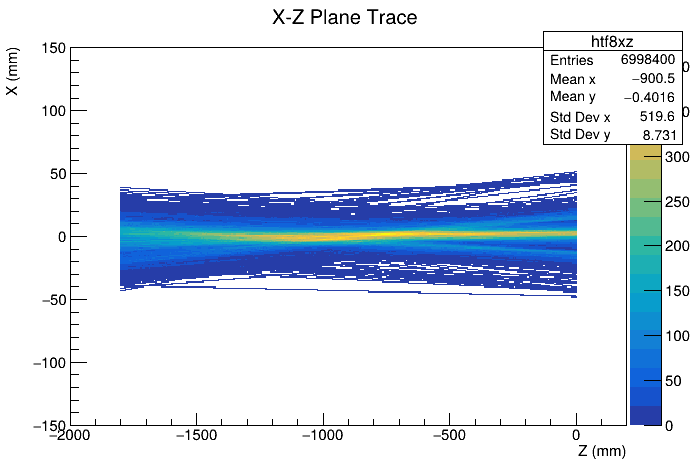

In [9]:
TH2 *hxz=(TH2*)f->Get("htf8xz");
hxz->Draw("colz");
c1->Draw();

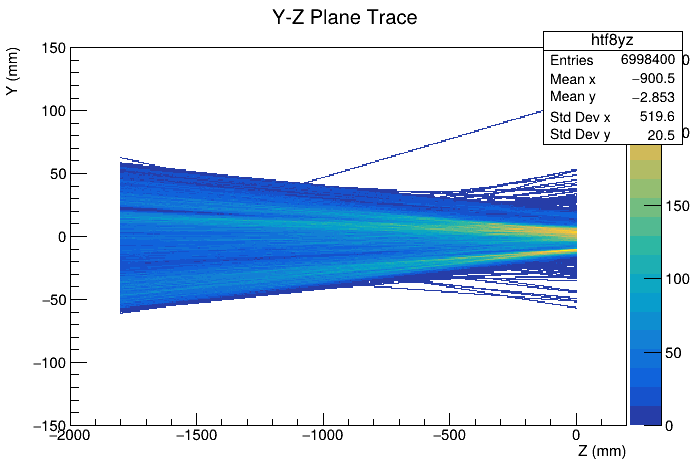

In [10]:
TH2 *hyz=(TH2*)f->Get("htf8yz");
hyz->Draw("colz");
c1->Draw();


<h3 id="%E6%9D%9F%E6%B5%81%E5%9C%A8%E9%9D%B6%E4%B8%8A%E6%8A%95%E5%BD%B1">束流在靶上投影</h3><ul>
<li>假设靶与束流线垂直。</li>
</ul>


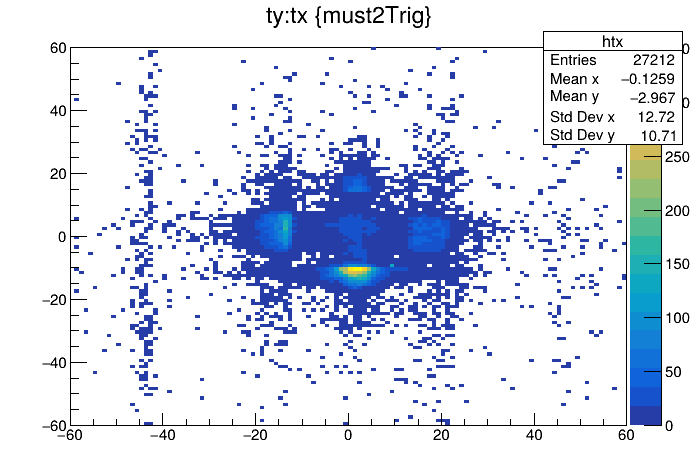

In [12]:
tree->Draw("ty:tx>>htx(120,-60,60,120,-60,60)","must2Trig","colz");
c1->Draw();

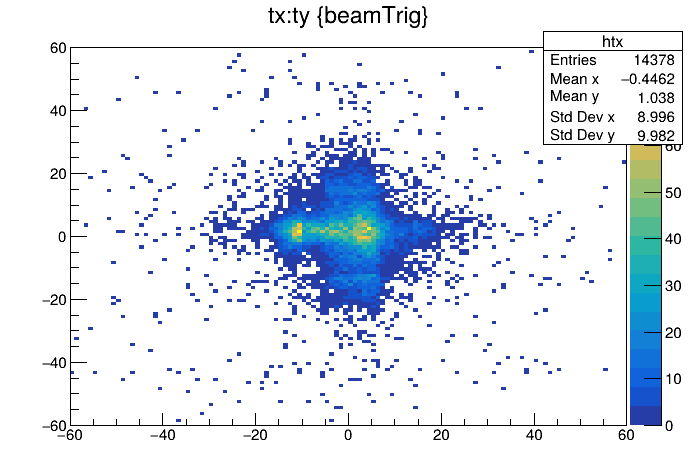

In [13]:
tree->Draw("tx:ty>>htx(120,-60,60,120,-60,60)","beamTrig","colz");
c1->Draw();


<p>$\chi^2/Ndf :  tx$</p>



<h3 id="%E6%AE%8B%E5%B7%AE%EF%BC%8Cchi2/NDF">残差，chi2/NDF</h3><ul>
<li>下图中呈现的残差分布并不是单一的gaus分布，有一个窄的gauss重叠在宽的gauss之上。这种现象在气体探测器中比较常见，其物理根源有：</li>
</ul>
<ol>
<li><strong>多重库仑散射 (MCS)：</strong> 高能束流穿过 PPAC 的镀铝Mylar或工作气体时，发生的卢瑟福散射天然具有非高斯的大角度拖尾。</li>
<li><strong>$\delta$ 电子 ：</strong> 入射粒子打出的高能次级电子在气体中横向游走，使得雪崩电荷的重心偏离了粒子真实的穿透点。</li>
<li><strong>电子学与束流本底：</strong>  Pile-up 或电子学的噪声。</li>
</ol>
<p>在实际的离线数据分析中，会使用 双高斯函数：窄核 + 宽尾对分布进行拟合。</p>
<ul>
<li><strong>宽尾（Tail）：</strong> 吸收由上述多重散射和 $\delta$ 电子造成的物理本底。</li>
<li><strong>窄核（Core）：</strong> 剥离本底后，<strong>只有这个窄核的高斯宽度（$\sigma_{core}$）才代表探测器真实的响应。</strong></li>
</ul>
<p>double-Gaussian 是描述 core 与 tail 的经验模型；宽分量不自动等于本底，窄分量 σ 也不自动等于探测器本征分辨。</p>

In [ ]:
TF1 *total2 = new TF1("total2", "gaus(0)+gaus(3)");

In [ ]:
TF1 *g1 = new TF1("g1", "gaus");
TF1 *g2 = new TF1("g2", "gaus");
TF1 *total = new TF1("total", "gaus(0) + gaus(3)");
TH1F *hdx;
Double_t sigma;

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      4053.25
NDf                       =          194
Edm                       =  1.69637e-06
NCalls                    =          205
p0                        =      15535.9   +/-   54.2825      	 (limited)
p1                        =   -0.0690366   +/-   0.000593738
p2                        =     0.216938   +/-   0.000651831  	 (limited)
p3                        =      852.798   +/-   8.09227      	 (limited)
p4                        =   -0.0870692   +/-   0.00572479
p5                        =      1.36868   +/-   0.00718109   	 (limited)
Core sigma=0.216938, tail sigma=1.36868 mm

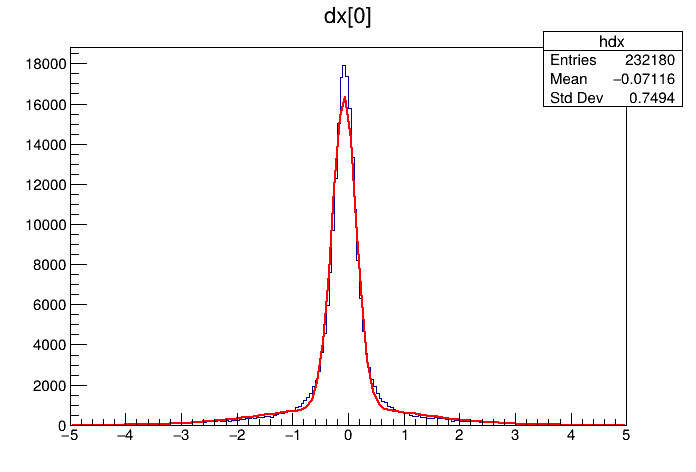

In [18]:
tree->Draw("dx[0]>>hdx(200,-5,5)");
TH1 *hdx = (TH1*)gROOT->FindObject("hdx");
g1->SetParameters(hdx->GetMaximum(),0,0.3);
hdx->Fit(g1,"Q","",-0.5,0.5);
double sigma = fabs(g1->GetParameter(2));
total->SetParameters(g1->GetParameter(0),g1->GetParameter(1),sigma,hdx->GetMaximum()*0.1,0,3*sigma);
total->SetParLimits(0,0,2*hdx->GetMaximum());
total->SetParLimits(3,0,2*hdx->GetMaximum());
total->SetParLimits(2,0.05,5);
total->SetParLimits(5,0.1,15);
TFitResultPtr residualFit=hdx->Fit(total,"S");
cout << "Core sigma=" << total->GetParameter(2) << ", tail sigma=" << total->GetParameter(5) << " mm" << endl;
gPad->SetLogy(0);
c1->Draw();

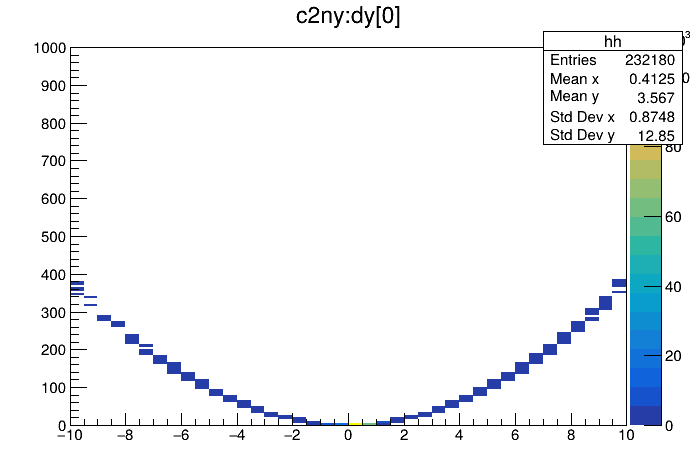

In [19]:
tree->Draw("c2ny:dy[0]>>hh(40,-10,10,200,0,1000)","","colz");
c1->SetLogy(0);
c1->Draw();//从chi2/ndf图上可看出，部分事件的径迹拟合误差很大，这部分要在后续数据处理中去掉。

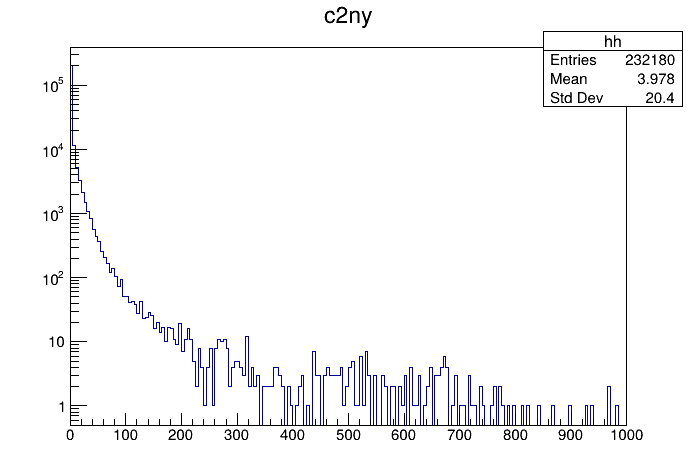

In [20]:
tree->Draw("c2ny>>hh(200,0,1000)","","");
gPad->SetLogy();
c1->Draw();//从chi2/ndf图上可看出，部分事件的径迹拟合误差很大，这部分要在后续数据处理中去掉。

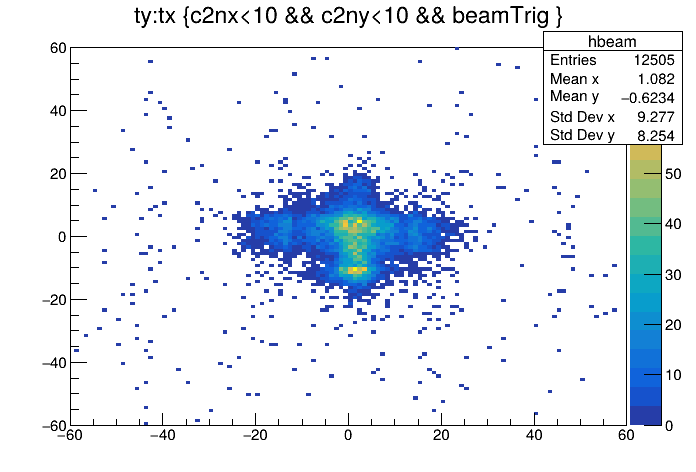

In [21]:
gPad->SetLogy(0);
tree->Draw("ty:tx>>hbeam(120,-60,60,120,-60,60)","c2nx<10 && c2ny<10 && beamTrig ","colz");
c1->Draw();//

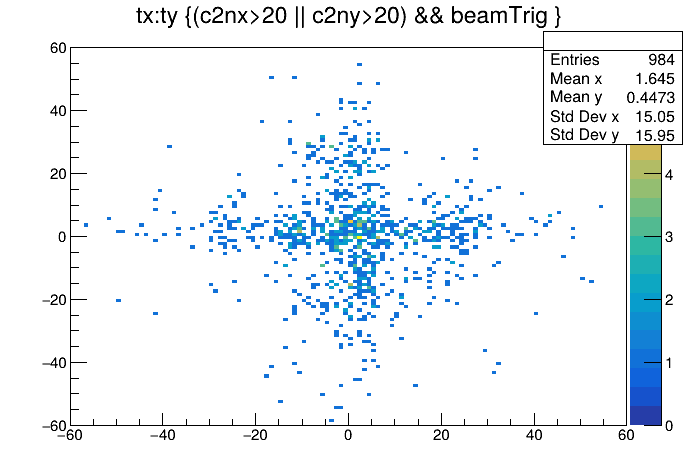

In [22]:
tree->Draw("tx:ty>>(120,-60,60,120,-60,60)","(c2nx>20 || c2ny>20) && beamTrig ","colz");
c1->Draw();//


<h2 id="PPAC2B-x,y,x-y%E7%9A%84%E6%8E%A2%E6%B5%8B%E6%95%88%E7%8E%87">PPAC2B x,y,x-y的探测效率</h2><p>在 ROOT 中，利用 <code>TCut</code>（条件切割）和 <code>TTree::GetEntries(selection)</code> 来快速统计满足特定物理条件的事件数，从而计算效率。</p>



<h3 id="0.-%E5%AE%9A%E4%B9%89%E7%89%A9%E7%90%86%E7%AD%9B%E9%80%89%E6%9D%A1%E4%BB%B6-(TCut)">0. 定义物理筛选条件 (TCut)</h3><p>首先，将复杂的逻辑判断定义为直观的 <code>TCut</code> 变量：</p>


In [ ]:
TCut c2btrack = "abs(xx2b[1])<100 && abs(yy2b[1])<60";
TCut c2ba = "anode2b>-900"; // -1000 是该文件的无效标记
TCut c2bx = "abs(xx2b[0])<120";
TCut c2by = "abs(yy2b[0])<75";


<h3 id="1.-%E8%AE%A1%E7%AE%97%E7%A9%BF%E8%BF%87%E6%8E%A2%E6%B5%8B%E5%99%A8%E7%81%B5%E6%95%8F%E9%9D%A2%E7%A7%AF%E7%9A%84%E9%A2%84%E6%9C%9F%E7%B2%92%E5%AD%90%E6%95%B0">1. 计算穿过探测器灵敏面积的预期粒子数</h3><p>利用刚才定义的 <code>c2btrack</code>，可以画出径迹在外推平面上的二维投影，并获取总入射事件数。</p>


预期穿过 PPAC2B 灵敏区的粒子总数 N_track = 232178

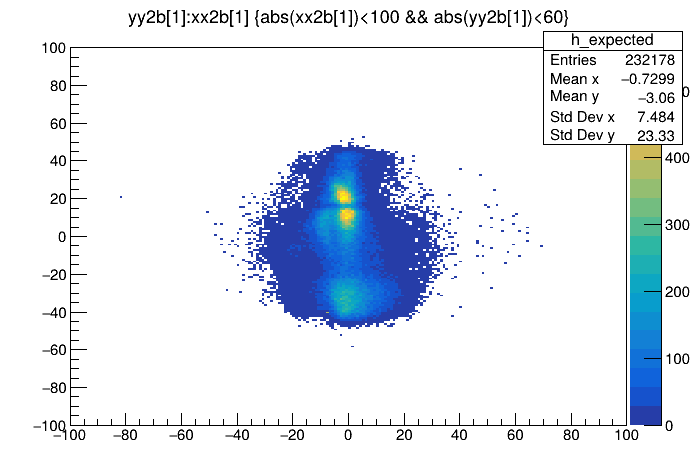

In [27]:
// 绘制外推位置的 2D 分布 (预期击中位置)
tree->Draw("yy2b[1]:xx2b[1]>>h_expected(200,-100,100,200,-100,100)", c2btrack, "colz");
c1->Draw();
// 统计预期穿过灵敏区域的总数
Long64_t N_track = tree->GetEntries(c2btrack);
cout << "预期穿过 PPAC2B 灵敏区的粒子总数 N_track = " << N_track << endl;


<h3 id="2.-%E8%AE%A1%E7%AE%97%E5%B9%B6%E5%AF%B9%E6%AF%94%E4%B8%A4%E7%B1%BB%E6%8E%A2%E6%B5%8B%E6%95%88%E7%8E%87">2. 计算并对比两类探测效率</h3><p><em>实际气态探测器的效率与入射粒子的种类 $(A, Z)$、能量以及击中位置均有关，示例代码求的是全局平均探测效率。</em></p>


In [ ]:
// 下面的分母为同一触发和 fiducial 区域内的 reference tracks。

In [30]:
Long64_t Ntrack = tree->GetEntries(c2btrack);
Long64_t Na = tree->GetEntries(c2btrack && c2ba);
Long64_t Nx = tree->GetEntries(c2btrack && c2bx);
Long64_t Ny = tree->GetEntries(c2btrack && c2by);
Long64_t Nxy = tree->GetEntries(c2btrack && c2bx && c2by);
if (Ntrack==0 || Na==0) throw std::runtime_error("empty efficiency denominator");
cout << "Reference tracks=" << Ntrack << ", anode=" << Na << endl;
for (Long64_t n : {Nx,Ny,Nxy}) {
    double eff = double(n)/Ntrack;
    cout << "eff=" << eff << " +/- " << sqrt(eff*(1-eff)/Ntrack) << endl;
}
Long64_t Nxa=tree->GetEntries(c2btrack && c2ba && c2bx);
Long64_t Nya=tree->GetEntries(c2btrack && c2ba && c2by);
Long64_t Nxya=tree->GetEntries(c2btrack && c2ba && c2bx && c2by);
cout << "Given anode: x=" << double(Nxa)/Na << ", y=" << double(Nya)/Na
     << ", xy=" << double(Nxya)/Na << endl;

Reference tracks=232178, anode=230382
eff=0.931156 +/- 0.000525452
eff=0.929791 +/- 0.000530248
eff=0.868683 +/- 0.00070094
Given anode: x=0.938415, y=0.937039, xy=0.875455

<h3>效率的含义</h3><p>这里得到的是 reference tracking 样本和指定面积内的条件效率。阳极触发条件下的效率用与阳极同时有效的 numerator，不能把未要求 anode 的 Nx 直接除以 Na。给出的误差是大样本 binomial 近似；x-y 联合效率直接计数，不假设 x、y 独立。</p><p>示例的 fiducial 区域是 |x|&lt;100 mm、|y|&lt;60 mm，位于探测器有效面内。比较不同触发或 reference 组合时使用相同区域，并同时报告分母。</p>


<h2 id="assignment">作业</h2><h3 id="Task-A:-%E7%89%A9%E7%90%86%E9%9D%B6%E7%82%B9%E5%A4%96%E6%8E%A8%E4%B8%8E%E9%87%8D%E5%BB%BA%E4%BF%A1%E6%81%AF%E8%AE%B0%E5%BD%95">Task A: 物理靶点外推与重建信息记录</h3><p>示例代码演示了固定的 3 层探测器（1A, 2A, 3）拟合。但在实际物理分析中，为了最大化统计量，我们需要利用 <code>F8PPAC1a, 1b, 2a, 2b, 3</code> 这 <strong>5 层</strong> 的所有有效位置信息，进行<strong>动态径迹重建</strong>。</p>
<p>修改示例代码：</p>
<h4 id="1.-%E5%BE%84%E8%BF%B9%E6%8B%9F%E5%90%88%E4%B8%8E%E7%8A%B6%E6%80%81%E8%AE%B0%E5%BD%95">1. 径迹拟合与状态记录</h4><ul>
<li><strong>筛选有效点：</strong> 对每一个事件，逐一检查 5 层 PPAC 是否给出了有效的位置坐标（排除 -999 或越界噪声）。</li>
<li><strong>状态记录：</strong> 引入变量 <code>Ndet_x</code> 和 <code>Ndet_y</code> 记录实际参与 $X$ 和 $Y$ 平面拟合的探测器层数（需满足 $N \ge 2$ 才可拟合）；引入数组 <code>DetHitX[5], DetHitY[5]</code> 记录具体是哪几层参与了拟合（1代表参与，0代表未参与）。</li>
</ul>
<h4 id="2.-%E9%9D%B6%E4%BD%8D%E5%9D%90%E6%A0%87">2. 靶位坐标</h4><ul>
<li><p>实验中，物理靶并非垂直放置，而是<strong>朝向望远镜倾斜了 $45^\circ$</strong>（靶的平面方程x+z=0 ）。</p>
</li>
<li><p><strong>求解靶上坐标：</strong> 请将空间直线方程 $x = f_x(z)$ 和 $y = f_y(z)$ 与倾斜的靶平面方程联立，解出束流打在靶面上的真实三维交点坐标 <code>targetX, targetY, targetZ</code>。</p>
</li>
<li><p>计算出靶上交点坐标的物理误差 ，以及束流入射方向的投影角误差 。</p>
</li>
<li><p>将上述所有拟合卡方值（<code>chi2/ndf</code>）、残差（Residual）、交点坐标及物理误差作为新 Branch 存入 TTree。</p>
</li>
</ul>
<h4 id="3.-%E6%95%B0%E6%8D%AE%E5%88%86%E6%9E%90">3. 数据分析</h4><ol>
<li><strong>传输效率计算：</strong> 在 <code>beamTrig</code>（束流触发）条件下，统计“重建的束流打在给定物理靶尺寸范围内”的事件数比例（即靶的几何接受度/传输效率 $\varepsilon_{target}$）。</li>
<li>分别画出不同策略下的事件在靶位上的位置以及散射角分布，以及各项的误差分布。</li>
</ol>
<h3 id="Task-B:-PPAC-%E6%8E%A2%E6%B5%8B%E6%95%88%E7%8E%87%E7%9A%84%E5%A4%9A%E9%87%8D%E9%AA%8C%E8%AF%81">Task B: PPAC 探测效率的多重验证</h3><p>计算位于最上游的 <code>PPAC1a</code> 和最下游的 <code>PPAC3</code> 的 $x$ 效率、$y$ 效率以及 $(x,y)$ 二维联合效率。</p>
<p>要求进行<strong>交叉验证</strong>：</p>
<ol>
<li><strong>对比效率类型：</strong> 分别计算它们的<strong>绝对探测效率</strong>（方法一：Tracking 外推作为分母）和<strong>位置读出效率</strong>（方法二：自身阳极信号作为分母）。</li>
<li>在使用 Tracking 方法时，尝试改变“参考探测器”的组合（例如：测 PPAC3 时，分别尝试用 <code>1a+2a</code> 拟合，或用 <code>1b+2b</code> 拟合），验证在不同基准下求出的效率值是否具有自洽性（结果应相近）。</li>
</ol>
<p>使用两层时记录 NDF=0，不计算 χ²/NDF。对不同 reference 组合比较效率时，检查共同的几何范围和样本条件，不预先要求结果相等。</p>